# 📊 03 – Exploratory Data Analysis (EDA)

In this notebook, we explore the cleaned dataset and identify patterns
related to fraudulent transactions.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv("../data/cleaned_data.csv")
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## 📌 Basic Dataset Overview

In [11]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   trans_date_trans_time  str    
 1   cc_num                 int64  
 2   merchant               str    
 3   category               str    
 4   amt                    float64
 5   first                  str    
 6   last                   str    
 7   gender                 str    
 8   street                 str    
 9   city                   str    
 10  state                  str    
 11  zip                    int64  
 12  lat                    float64
 13  long                   float64
 14  city_pop               int64  
 15  job                    str    
 16  dob                    str    
 17  trans_num              str    
 18  unix_time              int64  
 19  merch_lat              float64
 20  merch_long             float64
 21  is_fraud               int64  
dtypes: float64(5), int64(5), str(

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06
mean,4.173860e+17,7.006357e+01,4.881326e+04,3.853931e+01,-9.022783e+01,8.864367e+04,1.358674e+09,3.853898e+01,-9.022794e+01,5.210015e-03
std,1.309115e+18,1.592540e+02,2.688185e+04,5.071470e+00,1.374789e+01,3.014876e+05,1.819508e+07,5.105604e+00,1.375969e+01,7.199217e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902742e+01,-1.666716e+02,0.000000e+00
25%,1.800429e+14,9.640000e+00,2.623700e+04,3.466890e+01,-9.679800e+01,7.410000e+02,1.343017e+09,3.474012e+01,-9.689944e+01,0.000000e+00
50%,3.521417e+15,4.745000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.443000e+03,1.357089e+09,3.936890e+01,-8.744069e+01,0.000000e+00
75%,4.642255e+15,8.310000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.374581e+09,4.195626e+01,-8.024511e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.992100e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.388534e+09,6.751027e+01,-6.695090e+01,1.000000e+00


## ⚖️ Fraud vs Non-Fraud Distribution

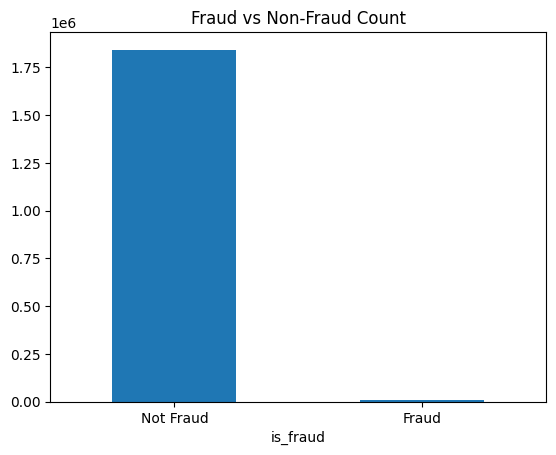

In [12]:
df['is_fraud'].value_counts().plot(kind='bar')
plt.title("Fraud vs Non-Fraud Count")
plt.xticks([0,1], ['Not Fraud', 'Fraud'], rotation=0)
plt.show()

## 💰 Transaction Amount Distribution

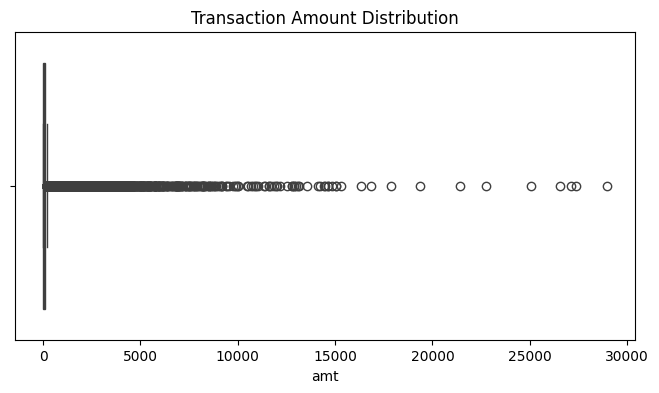

In [13]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['amt'])
plt.title("Transaction Amount Distribution")
plt.show()

## 🛒 Fraud Count by Merchant Category

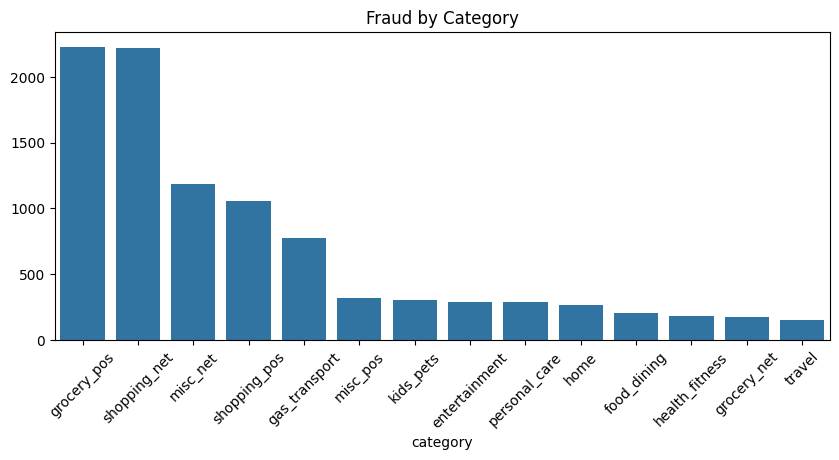

In [14]:
fraud_cat = df[df['is_fraud']==1]['category'].value_counts()

plt.figure(figsize=(10,4))
sns.barplot(x=fraud_cat.index, y=fraud_cat.values)
plt.xticks(rotation=45)
plt.title("Fraud by Category")
plt.show()

## 📈 Fraud vs Non-Fraud Amount Comparison

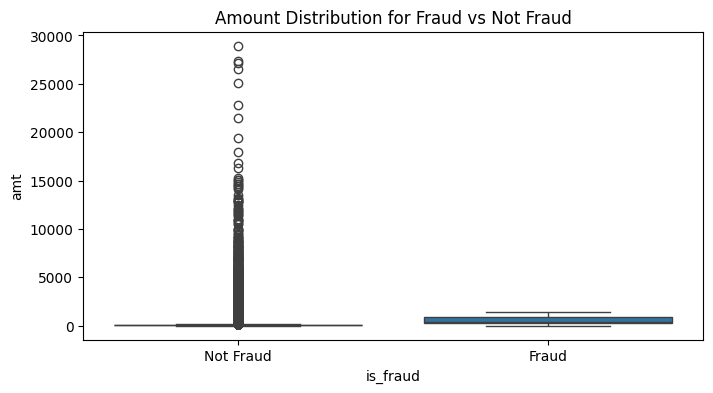

In [15]:
plt.figure(figsize=(8,4))
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.title("Amount Distribution for Fraud vs Not Fraud")
plt.xticks([0,1], ['Not Fraud', 'Fraud'])
plt.show()

In [16]:
df['hour'] = pd.to_datetime(df['trans_date_trans_time']).dt.hour

## 🕒 Fraud by Hour of Day

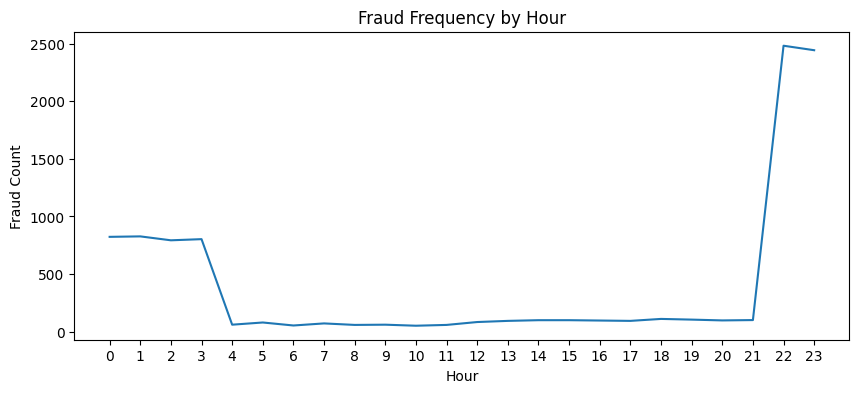

In [17]:
fraud_hour = df[df['is_fraud']==1]['hour'].value_counts().sort_index()

plt.figure(figsize=(10,4))
sns.lineplot(x=fraud_hour.index, y=fraud_hour.values)
plt.title("Fraud Frequency by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Count")
plt.xticks(range(0,24))
plt.show()

## 🔥 Correlation Heatmap (Numerical Features)

<Figure size 1200x800 with 0 Axes>

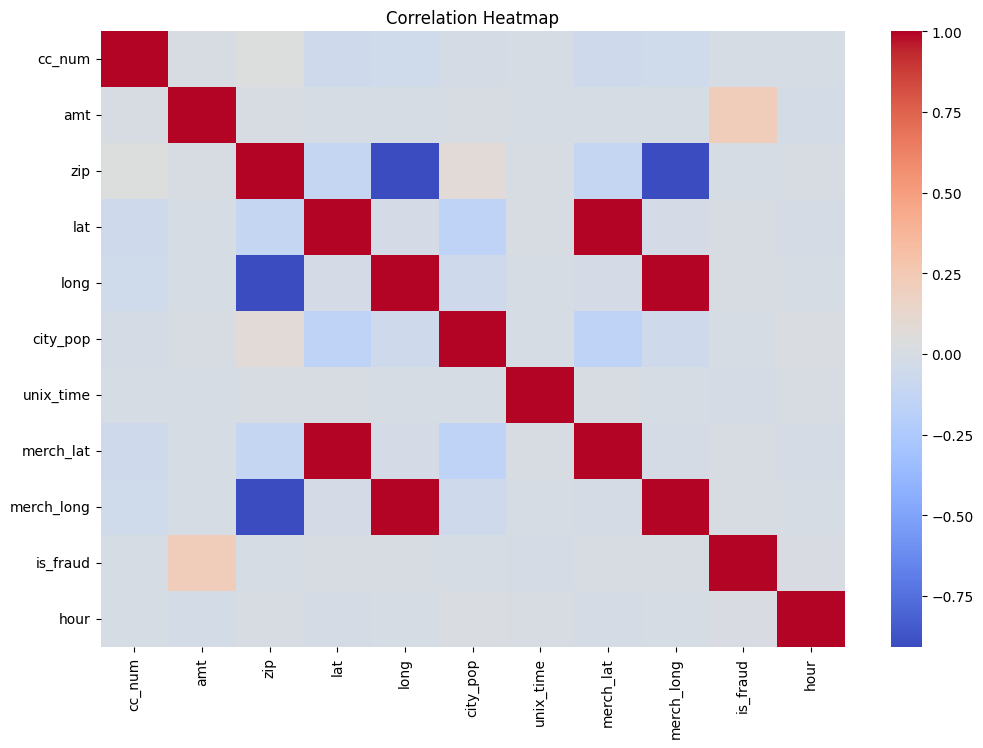

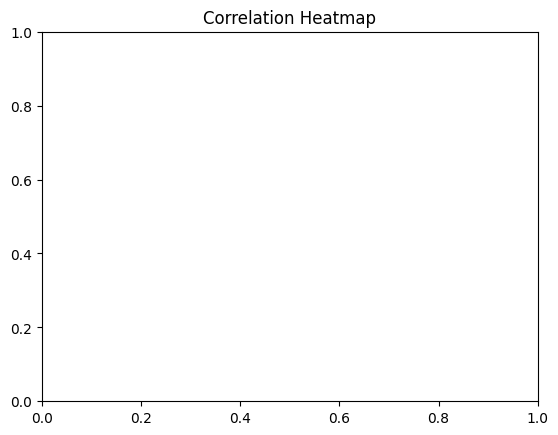

In [18]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32'])
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
plt.title("Correlation Heatmap")
plt.show()